# Classificação de Atividade Humana com PCA

Vamos trabalhar com a base da demonstração feita em aula, mas vamos explorar um pouco melhor como é o desempenho da árvore variando o número de componentes principais.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from time import perf_counter

In [21]:
BASE_DIR = Path(r"C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input")

dataset_dir = BASE_DIR / "UCI HAR Dataset"

# fallback: se a pasta não estiver exatamente assim, tenta localizar automaticamente pelo features.txt
if not dataset_dir.exists():
    achados = list(BASE_DIR.rglob("features.txt"))
    if len(achados) == 0:
        raise FileNotFoundError(f"Não encontrei 'features.txt' dentro de: {BASE_DIR}")
    dataset_dir = achados[0].parent

print("Dataset encontrado em:")
print(dataset_dir)

filename_features = dataset_dir / "features.txt"
filename_labels   = dataset_dir / "activity_labels.txt"

filename_subtrain = dataset_dir / "train" / "subject_train.txt"
filename_xtrain   = dataset_dir / "train" / "X_train.txt"
filename_ytrain   = dataset_dir / "train" / "y_train.txt"

filename_subtest  = dataset_dir / "test" / "subject_test.txt"
filename_xtest    = dataset_dir / "test" / "X_test.txt"
filename_ytest    = dataset_dir / "test" / "y_test.txt"

# checagem rápida
arquivos = {
    "features": filename_features,
    "labels": filename_labels,
    "subtrain": filename_subtrain,
    "xtrain": filename_xtrain,
    "ytrain": filename_ytrain,
    "subtest": filename_subtest,
    "xtest": filename_xtest,
    "ytest": filename_ytest,
}
print("\nArquivos existem?")
for k, v in arquivos.items():
    print(f"{k:8} -> {v.exists()} | {v}")

Dataset encontrado em:
C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset

Arquivos existem?
features -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\features.txt
labels   -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\activity_labels.txt
subtrain -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\train\subject_train.txt
xtrain   -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\train\X_train.txt
ytrain   -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\train\y_train.txt
subtest  -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\test\subject_test.txt
xtest    -> True | C:\Users\Priscila\Desktop\EBAC - DATA SCIENCE\PCA\Pratique II\input\UCI HAR Dataset\test\X_test.txt
ytest    -> True | C:\

In [22]:
print("Shape X_train:", X_train.shape)
print("Tipos (primeiras colunas):")
print(X_train.dtypes.head())
X_train.head()

Shape X_train: (7352, 561)
Tipos (primeiras colunas):
0    float64
1    float64
2    float64
3    float64
4    float64
dtype: object


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


## PCA com variáveis padronizadas

Reflexão sobre a escala das variáveis:

**Variáveis em métricas muito diferentes** podem interferir na análise de componentes principais. Lembra que variância é informação pra nós? Pois bem, tipicamente se há uma variável monetária como salário, vai ter uma ordem de variabilidade bem maior que número de filhos, tempo de emprego ou qualquer variável dummy. Assim, as variáveis de maior variância tendem a "dominar" a análise. Nesses casos é comum usar a padronização das variáveis.

Faça duas análises de componentes principais para a base do HAR - com e sem padronização e compare:

- A variância explicada por componente
- A variância explicada acumulada por componente
- A variância percentual por componente
- A variância percentual acumulada por componente
- Quantas componentes você escolheria, em cada caso para explicar 90% da variância?

In [23]:
%%time

pca_raw = PCA()
pca_raw.fit(X_train)

var_ratio_raw = pca_raw.explained_variance_ratio_
var_cum_raw = np.cumsum(var_ratio_raw)

k90_raw = int(np.argmax(var_cum_raw >= 0.90) + 1)

df_pca_raw = pd.DataFrame({
    "componente": np.arange(1, len(var_ratio_raw) + 1),
    "var_explicada": var_ratio_raw,
    "var_explicada_%": var_ratio_raw * 100,
    "var_acumulada": var_cum_raw,
    "var_acumulada_%": var_cum_raw * 100
})

print(f"Componentes necessárias para explicar >= 90% (SEM padronização): {k90_raw}")
print("Linha onde bate 90% (SEM padronização):")
print(df_pca_raw.iloc[k90_raw-1])
df_pca_raw.head()

Componentes necessárias para explicar >= 90% (SEM padronização): 34
Linha onde bate 90% (SEM padronização):
componente         34.000000
var_explicada       0.002359
var_explicada_%     0.235866
var_acumulada       0.900937
var_acumulada_%    90.093709
Name: 33, dtype: float64
CPU times: total: 391 ms
Wall time: 56.1 ms


,componente,var_explicada,var_explicada_%,var_acumulada,var_acumulada_%
0,1,0.625544,62.554440,0.625544,62.554440
1,2,0.049130,4.913023,0.674675,67.467463
2,3,0.041215,4.121467,0.715889,71.588930
3,4,0.018750,1.874956,0.734639,73.463886
4,5,0.016949,1.694860,0.751587,75.158746


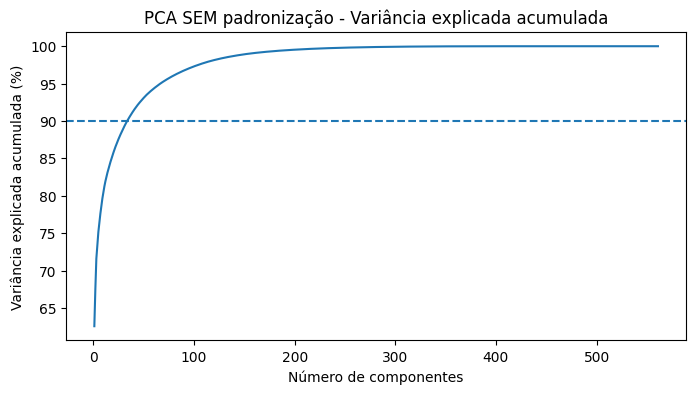

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(df_pca_raw["componente"], df_pca_raw["var_acumulada_%"])
plt.axhline(90, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada (%)")
plt.title("PCA SEM padronização - Variância explicada acumulada")
plt.show()

In [25]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns)

print("Shape X_train_std:", X_train_std.shape)
print("Média (aprox.) das primeiras colunas:")
print(X_train_std.mean().head())
print("Desvio padrão (aprox.) das primeiras colunas:")
print(X_train_std.std(ddof=0).head())
X_train_std.head()

Shape X_train_std: (7352, 561)
Média (aprox.) das primeiras colunas:
0   -3.131336e-16
1    4.783986e-17
2    8.698156e-17
3   -1.507680e-16
4    0.000000e+00
dtype: float64
Desvio padrão (aprox.) das primeiras colunas:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.200642,-0.063683,-0.419628,-0.868814,-0.939441,-0.737529,-0.859817,-0.939019,-0.766437,-0.856036,...,-0.795359,0.025960,-0.276399,-0.360603,0.062940,-0.778427,-0.026080,-0.687219,0.407946,-0.007568
1,0.055948,0.031486,-0.253908,-0.875426,-0.923902,-0.849304,-0.868531,-0.921998,-0.848928,-0.871359,...,0.130614,-0.897357,-0.767990,0.133011,-0.021461,-1.218805,1.484470,-0.694138,0.409117,0.007875
2,0.073515,-0.043416,-0.076295,-0.869039,-0.907760,-0.893785,-0.863137,-0.898854,-0.896701,-0.863323,...,1.152336,-0.260878,-0.438316,-0.377840,0.391976,0.151207,1.704201,-0.702239,0.410288,0.026502
3,0.066696,-0.208422,-0.249712,-0.870626,-0.940022,-0.921805,-0.864503,-0.938124,-0.925279,-0.863323,...,1.112769,0.591045,0.463155,-0.135025,-0.033637,1.037851,-1.003019,-0.701684,0.414650,0.031714
4,0.030469,0.027587,-0.109848,-0.875188,-0.934878,-0.921343,-0.867384,-0.931789,-0.928028,-0.870260,...,-0.149577,-0.138515,-0.240313,0.340406,0.268486,1.125918,-1.276282,-0.700152,0.425463,0.045225


In [26]:
pca_std = PCA()
pca_std.fit(X_train_std)

var_ratio_std = pca_std.explained_variance_ratio_
var_cum_std = np.cumsum(var_ratio_std)

k90_std = int(np.argmax(var_cum_std >= 0.90) + 1)

df_pca_std = pd.DataFrame({
    "componente": np.arange(1, len(var_ratio_std) + 1),
    "var_explicada": var_ratio_std,
    "var_explicada_%": var_ratio_std * 100,
    "var_acumulada": var_cum_std,
    "var_acumulada_%": var_cum_std * 100
})

print(f"Componentes necessárias para explicar >= 90% (COM padronização): {k90_std}")
print("Linha onde bate 90% (COM padronização):")
print(df_pca_std.iloc[k90_std-1])
df_pca_std.head()

Componentes necessárias para explicar >= 90% (COM padronização): 63
Linha onde bate 90% (COM padronização):
componente         63.000000
var_explicada       0.001761
var_explicada_%     0.176085
var_acumulada       0.900535
var_acumulada_%    90.053451
Name: 62, dtype: float64


,componente,var_explicada,var_explicada_%,var_acumulada,var_acumulada_%
0,1,0.507812,50.781172,0.507812,50.781172
1,2,0.065807,6.580680,0.573619,57.361853
2,3,0.028064,2.806437,0.601683,60.168289
3,4,0.025040,2.503953,0.626722,62.672242
4,5,0.018883,1.888285,0.645605,64.560527


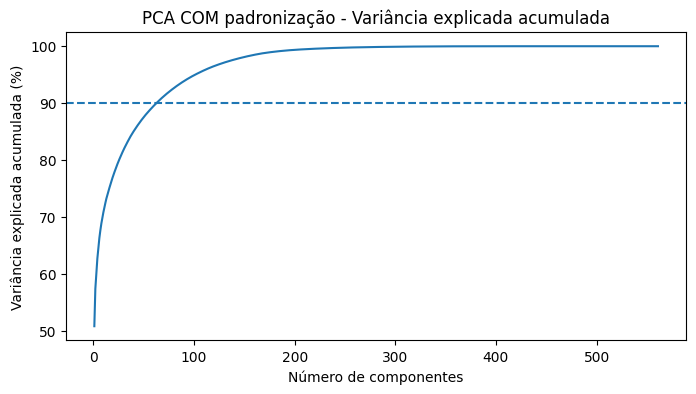

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(df_pca_std["componente"], df_pca_std["var_acumulada_%"])
plt.axhline(90, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada (%)")
plt.title("PCA COM padronização - Variância explicada acumulada")
plt.show()

In [28]:
df_comp = pd.DataFrame({
    "cenario": ["Sem padronização", "Com padronização"],
    "componentes_para_90%": [k90_raw, k90_std]
})

print("Resumo (componentes para atingir 90%):")
print(df_comp)
df_comp.head()

Resumo (componentes para atingir 90%):
            cenario  componentes_para_90%
0  Sem padronização                    34
1  Com padronização                    63


,cenario,componentes_para_90%
0,Sem padronização,34
1,Com padronização,63


## Árvore com PCA

Faça duas uma árvore de decisão com 10 componentes principais - uma com base em dados padronizados e outra sem padronizar. Utilize o ```ccp_alpha=0.001```.

Compare a acurácia na base de treino e teste.

In [29]:
%%time

ytr = np.ravel(y_train)
yte = np.ravel(y_test)

# Mantendo X_train/X_test como estão (DataFrame ou array)
Xtr = X_train
Xte = X_test

print("Shapes (checagem rápida):")
print("X_train:", getattr(Xtr, "shape", None))
print("y_train:", ytr.shape)
print("X_test :", getattr(Xte, "shape", None))
print("y_test :", yte.shape)

Shapes (checagem rápida):
X_train: (7352, 561)
y_train: (7352,)
X_test : (2947, 561)
y_test : (2947,)
CPU times: total: 0 ns
Wall time: 1 ms


In [33]:
%%time

pipe_sem_pad = Pipeline(steps=[
    ("pca", PCA(n_components=10)),
    ("arvore", DecisionTreeClassifier(random_state=42, ccp_alpha=0.001))
])

t0 = perf_counter()
pipe_sem_pad.fit(Xtr, ytr)
t1 = perf_counter()

pred_train_sem = pipe_sem_pad.predict(Xtr)
pred_test_sem  = pipe_sem_pad.predict(Xte)
t2 = perf_counter()

acc_train_sem = accuracy_score(ytr, pred_train_sem)
acc_test_sem  = accuracy_score(yte, pred_test_sem)

tempo_treino_sem = t1 - t0
tempo_pred_sem   = t2 - t1
tempo_total_sem  = t2 - t0

print("2.1) Árvore + PCA(10) — SEM padronização")
print(f"Acurácia (treino): {acc_train_sem:.4f}")
print(f"Acurácia (teste) : {acc_test_sem:.4f}")
print(f"Tempo treino (s) : {tempo_treino_sem:.4f}")
print(f"Tempo pred (s)   : {tempo_pred_sem:.4f}")
print(f"Tempo total (s)  : {tempo_total_sem:.4f}")

2.1) Árvore + PCA(10) — SEM padronização
Acurácia (treino): 0.8927
Acurácia (teste) : 0.8242
Tempo treino (s) : 0.1530
Tempo pred (s)   : 0.0130
Tempo total (s)  : 0.1660
CPU times: total: 1.22 s
Wall time: 167 ms


In [34]:
%%time

pipe_com_pad = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("arvore", DecisionTreeClassifier(random_state=42, ccp_alpha=0.001))
])

t0 = perf_counter()
pipe_com_pad.fit(Xtr, ytr)
t1 = perf_counter()

pred_train_com = pipe_com_pad.predict(Xtr)
pred_test_com  = pipe_com_pad.predict(Xte)
t2 = perf_counter()

acc_train_com = accuracy_score(ytr, pred_train_com)
acc_test_com  = accuracy_score(yte, pred_test_com)

tempo_treino_com = t1 - t0
tempo_pred_com   = t2 - t1
tempo_total_com  = t2 - t0

print("2.2) Árvore + StandardScaler + PCA(10) — COM padronização")
print(f"Acurácia (treino): {acc_train_com:.4f}")
print(f"Acurácia (teste) : {acc_test_com:.4f}")
print(f"Tempo treino (s) : {tempo_treino_com:.4f}")
print(f"Tempo pred (s)   : {tempo_pred_com:.4f}")
print(f"Tempo total (s)  : {tempo_total_com:.4f}")

2.2) Árvore + StandardScaler + PCA(10) — COM padronização
Acurácia (treino): 0.8587
Acurácia (teste) : 0.7672
Tempo treino (s) : 0.1677
Tempo pred (s)   : 0.0332
Tempo total (s)  : 0.2009
CPU times: total: 1.19 s
Wall time: 202 ms


In [32]:
df_comp = pd.DataFrame([
    {
        "cenario": "Sem padronização",
        "acc_treino": acc_train_sem,
        "acc_teste": acc_test_sem,
        "tempo_treino_s": tempo_treino_sem,
        "tempo_pred_s": tempo_pred_sem,
        "tempo_total_s": tempo_total_sem
    },
    {
        "cenario": "Com padronização",
        "acc_treino": acc_train_com,
        "acc_teste": acc_test_com,
        "tempo_treino_s": tempo_treino_com,
        "tempo_pred_s": tempo_pred_com,
        "tempo_total_s": tempo_total_com
    }
])

print("Resumo comparativo — Árvore com PCA (10 componentes):")
print(df_comp.to_string(index=False))
df_comp.head()

Resumo comparativo — Árvore com PCA (10 componentes):
         cenario  acc_treino  acc_teste  tempo_treino_s  tempo_pred_s  tempo_total_s
Sem padronização    0.892682   0.824228        0.132772      0.014039       0.146811
Com padronização    0.858678   0.767221        0.172700      0.037931       0.210631


,cenario,acc_treino,acc_teste,tempo_treino_s,tempo_pred_s,tempo_total_s
0,Sem padronização,0.892682,0.824228,0.132772,0.014039,0.146811
1,Com padronização,0.858678,0.767221,0.172700,0.037931,0.210631
